**Why Signatures Were Not Used in This VAE Implementation**

While the approach by Bühler et al. (2020) demonstrates that signature-based
representations are highly effective for financial time series generation in
small data environments, I opted not to use signatures in my 3-day VAE
exploration for the following reasons:

1. **Different Task Objective**: The paper uses signatures to generate realistic
   synthetic price paths. My task is interval boundary detection within existing
   HR paths—a fundamentally different objective. The paper's signature-to-path
   decoding (via evolutionary algorithms) doesn't directly translate to
   signature-to-boundary prediction.

2. **Existing Feature Engineering**: I have already developed 30 domain-specific
   features (intervals_per_minute, expected_interval_length, HR derivatives,
   rolling statistics, etc.) that capture session structure and temporal patterns.
   These features serve a similar role to signatures in encoding path information
   efficiently for my specific task.

3. **Time Constraints**: With only 3 days allocated to explore the VAE approach,
   implementing signature computation, understanding the iisignature library,
   and developing a signature-to-boundary decoder would risk not completing any
   working implementation. I prioritized testing whether the VAE architecture
   itself (the paper's core contribution for small data) provides value over my
   baseline XGBoost model.

4. **Implementation Complexity**: Converting signatures back to boundary locations
   is non-trivial and not directly addressed in the paper. The paper's inverse
   signature transform generates continuous paths, whereas I need discrete
   boundary indices—requiring additional methodology development.

I implemented the VAE architecture using my engineered features as input,
following the same ELBO optimization and conditional generation principles
demonstrated in Bühler et al. Signatures remain a promising direction for
future work if the VAE approach shows merit.

## Imports

In [1]:
# ============================================================================
# 1. IMPORTS AND SETUP
# ============================================================================

import numpy as np
import pandas as pd
import os
from typing import Dict, List, Tuple
from dataclasses import dataclass
from sklearn.preprocessing import StandardScaler
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import random
warnings.filterwarnings('ignore')

# VAE imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
RANDOM_SEED = 123
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

# Visualization settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

print("✓ Imports complete")

✓ Imports complete


## Configuration

In [2]:
# ============================================================================
# 2. CONFIGURATION
# ============================================================================

@dataclass
class Config:
    """Configuration for the VAE segmentation pipeline."""
    random_seed: int = 123

    # Feature engineering windows (in seconds)
    short_window: int = 20
    medium_window: int = 30
    long_window: int = 60

    # Post-processing for peak detection
    peak_distance: int = 20
    peak_prominence: float = 0.15
    smooth_sigma: float = 3.0

CONFIG = Config()
print(f"✓ Configuration set")

✓ Configuration set


## Data Configuration

Inkludiert nun 93 workout sessions.

Bei den neuen SpecialBikes Sessions waren auch zwei Rudereinheiten dabei.
Grundsätzlich ist zumindest die "Resting HR" in den Fit Files vorhanden. Aber nachdem das Model die Zones zurzeit nicht verwendet, sind sie nicht inkludiert.

In [3]:
# Your athlete data
athletes = {
    "Athlete12": {
        "sport": "rowing",
        "ftp": 230,
        "fit_dir": "AthleteDataCoding/Athlete12/OGs",
        "label_dir": "AthleteDataCoding/Athlete12/GTs",
        "allowed_files": {
            "10536403349_5006_row.fit",
            "10543962115_10006_row.fit",
            "10551999765_10006_row.fit",
            "10652950510_Btchen_fahren.fit",
            "10674304801_Btchen_fahren_in_Etappen_3.fit",
            "10694767945_Btchen_fahren_.fit",
            "10809067165_3007_row.fit",
            "11636429453_4558_row.fit",
            "11783093951_4x2000_sub8.fit",
            "11791568584_.fit",
            "11808467517_.fit",
            "11838948742_3006_row.fit",
            "11846980624_Platt_.fit",
            "11855866225_In_den_Seilen.fit",
            "11864381887_Catwalk_.fit",
            "11912062341_500er_in_grau.fit",
            "11962243206_Wundmanagement.fit",
            "11971395278_Use_it_or_lose_it.fit",
            "11987690514_Besser_als_Nix.fit",
            "11994450315_Airobics.fit",
            "12036692734_Exhausted.fit",
            "12069656901_Schwitzen_im_Sitzen.fit",
            "12501679452_Zustand_nach_Xtem_Atemwegsinfekt.fit",
            "12806981726_Row_Stretch__Stabi.fit",
            "12846436186_Synchronflug.fit",
            "12927701413_I_have_no_idea_when_Ill_be_back_in_serious_training_routine_but_at_least_we_have_a_kitchen.fit",
            "12951604563_DienstSport.fit",
            "13010348229_1h_w_4x1_intensity.fit",
            "13039020832_Analytiker.fit",
            "13280559542_Warm_up_rowing.fit",
            "13300350440_W_Up.fit",
            "13363035398_SGAktiv.fit",
            "13582048984_W_Up.fit",
            "13583093636_Afterburner_.fit",
            "13601462878_Zehnbauer.fit",
            "13609970768_Uffwrme.fit",
            "13610691264_1x_Crescendo.fit",
            "13618782252_3x5.fit",
            "13643807487_Nachfitten.fit",
            "13662882990_Heldentod.fit",
            "13672121049_Base_Miles.fit",
            "13688068283_Luftpresser.fit",
            "13918354210_W_Upen.fit",
            "13957096402_Technik.fit",
            "13971240869_A_ella_le_gusta.fit",
            "13974345688_Nochmaaaal.fit",
            "13983533934_Technik__30er.fit",
            "14001095362_Wer_will_der_kann_.fit",
            "14038989670__Hyperthermie_.fit",
            "14077735636_Base.fit",
            "14089880174_Zn_IKEA.fit",
            "14114545767_Dampfnudel.fit",
            "14125110656_Vallah_isch_balla.fit",
            "14135321532_Pimp_my_ride.fit",
            "14156450361_On_a_mission.fit",
            "14174927764_Dunstabzugshaubenselfie.fit",
            "14182817844_The_Emptiness_Machine.fit",
            "14260930602_3x1010_SubThr.fit",
            "14313279747_Vernunft_verliert_.fit",
            "14374019349_Uff.fit",
            "14396237986_4659_row.fit"
        },
    },
    "Athlete2": {
        "sport": "biking",
        "ftp": 341,
        "fit_dir": "AthleteDataCoding/Athlete2/OGs",
        "label_dir": "AthleteDataCoding/Athlete2/GTs",
        "allowed_files": "all"
    },

    "AthletesSpecialBike": {
        "sport": "biking",
        "ftp": None,
        "fit_dir": None,
        "label_dir": "AthleteDataCoding/SpecialBike_Labeled_NotSorted_Biking/GTs",
        "allowed_files": "all"
    },

    "AthletesSpecialRowing": {
    "sport": "rowing",
    "ftp": None,
    "fit_dir": None,
    "label_dir": "AthleteDataCoding/SpecialBike_Labeled_NotSorted_Rowing/GTs",
    "allowed_files": "all"
    }
}

# Test sessions (held out for evaluation)
test_sessions = [
    ("Athlete2", "13363782092_Zwift__Aerobic_Mixup_in_New_York"),
    ("Athlete2", "i65696340_Zwift__LC16_Lactate_Clearance_Over_Under_in_Watopia"),
    ("Athlete12", "13601462878_Zehnbauer"),
    ("Athlete12", "12036692734_Exhausted"),
    ("Athlete12", "12846436186_Synchronflug"),
    ("Athlete12", "11962243206_Wundmanagement"),
    ("Athlete12", "13688068283_Luftpresser"),
    ("Athlete12", "11783093951_4x2000_sub8"),
    ("Athlete12", "13983533934_Technik__30er"),
    ("Athlete12", "11846980624_Platt_"),
    ("Athlete12", "14125110656_Vallah_isch_balla"),
    ("Athlete12", "12069656901_Schwitzen_im_Sitzen"),
    ("Athlete12", "12989160676_Wohnzimmerromantik"),
    ("Athlete12", "14089880174_Zn_IKEA"),
    ("AthletesSpecialBike", "6697827529_Zwift__VO2max_1h110"),
    ("AthletesSpecialBike", "14691322045_Zwift__3x12min_3030_4x2min_Vo2Max_on_Road_to_Sky_in_Watopia"),
    ("AthletesSpecialBike", "10283878603_Zwift__HIT__HIT_EB_5x3_min_in_Watopia"),
    ("AthletesSpecialBike", "13557212506_Zwift__HIT__HIT_EB_7x2_min_VLamax_Pusher_in_Watopia"),
    ("AthletesSpecialRowing", "14612015090_3x_6x_3030")
]

print(f"✓ Data configuration loaded")
print(f"  Athletes: {list(athletes.keys())}")
print(f"  Test sessions: {len(test_sessions)}")

✓ Data configuration loaded
  Athletes: ['Athlete12', 'Athlete2', 'AthletesSpecialBike', 'AthletesSpecialRowing']
  Test sessions: 19


5. Feature Engineering Functions

Feature engineering: Extract 30 most important statistical, temporal, and derivative features from heart rate time series data for a single workout session.
These 30 features were pre-selected based on feature importance scores from prior model training.

In [4]:
def create_hr_features(df: pd.DataFrame, config: Config, n_expected_intervals: int = None) -> pd.DataFrame:

    # Initialize empty DataFrame to store all engineered features (preserves original index/timestamps)
    features = pd.DataFrame(index=df.index)

    # Extract heart rate values as numpy array for faster computation
    hr = df['heart_rate'].values

    # ==================== SESSION-LEVEL STATISTICS ====================
    # Calculate global statistics across the entire workout session
    # These provide context about the overall intensity and variability of the workout
    session_mean = hr.mean()           # Average HR for the session (baseline fitness reference)
    session_std = hr.std()             # Standard deviation (measure of HR variability)
    session_max = hr.max()             # Peak HR reached during session
    session_min = hr.min()             # Lowest HR (typically resting/recovery)
    session_range = session_max - session_min  # Total HR range (intensity span)
    session_p25 = np.percentile(hr, 25)  # 25th percentile (lower quartile - recovery zones)
    session_p75 = np.percentile(hr, 75)  # 75th percentile (upper quartile - high intensity zones)
    session_iqr = session_p75 - session_p25  # Interquartile range (robust measure of spread)

    # ==================== INTERVAL DENSITY FEATURES (Top 2) ====================
    # These features capture workout structure/pacing information
    if n_expected_intervals is not None:
        session_duration = (df['timestamp'].iloc[-1] - df['timestamp'].iloc[0]).total_seconds()  # Total number of seconds in the workout
        # Average length of each interval in seconds (helps model understand workout density)
        expected_interval_length = session_duration / n_expected_intervals
        # How many intervals occur per minute (pacing metric: high = short intervals, low = long intervals)
        intervals_per_minute = n_expected_intervals / (session_duration / 60)

        features['intervals_per_minute'] = intervals_per_minute  # Rank 1 - Most important feature (0.1135)
        features['expected_interval_length'] = expected_interval_length  # Rank 2 - Second most important (0.0714)

    # ==================== SMOOTHED HR ====================
    # Apply rolling averages to reduce noise and reveal underlying trends
    # center=True: window is centered on current point (uses past and future data)
    # min_periods=1: compute even at edges where full window isn't available
    features['hr_smooth_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).mean()
    features['hr_smooth_long'] = df['heart_rate'].rolling(window=config.long_window, center=True, min_periods=1).mean()

    # ==================== NORMALIZED HR FEATURES ====================
    # Z-score normalization: converts HR to "standard deviations from mean"
    # Makes features comparable across different individuals/fitness levels
    # +1e-6 prevents division by zero if std is 0
    features['hr_smooth_medium_normalized'] = (features['hr_smooth_medium'] - session_mean) / (session_std + 1e-6)  # Rank 3

    # ==================== TEMPORAL FEATURES ====================
    # Look-ahead features: what is the HR going to be in the future?
    # Negative shift means "look forward in time"
    # These are powerful because boundaries show different HR 30-60s later
    features['hr_lead_30s'] = df['heart_rate'].shift(-30)  # HR 30 seconds in the future - Rank 4
    features['hr_lead_60s'] = df['heart_rate'].shift(-60)  # HR 60 seconds in the future - Rank 5

    # ==================== ROLLING STATISTICS ====================
    # Calculate statistics over medium-sized windows (40s by default)
    features['hr_max_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).max()
    features['hr_min_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).min()
    # Range within the window (high range = variable/transitioning HR, low range = steady state)
    features['hr_range_medium'] = features['hr_max_medium'] - features['hr_min_medium']  # Rank 6
    # Standard deviation within window (another variability measure)
    features['hr_std_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).std()

    # ==================== RELATIVE FEATURES ====================
    # Difference from long-term baseline (detects deviations from sustained HR level)
    # Positive = above baseline (working hard), negative = below baseline (recovering)
    features['hr_vs_long_baseline'] = hr - features['hr_smooth_long']  # Rank 7

    # ==================== SESSION-NORMALIZED FEATURES ====================
    # Compare current HR to key session statistics
    features['hr_vs_session_p75'] = hr - session_p75  # Rank 8 - Distance from high-intensity threshold

    # Change from past to future (60s lag to 60s lead = 120s total span)
    # Large positive = HR is rising dramatically, large negative = HR is dropping
    features['hr_change_past_to_future'] = features['hr_lead_60s'] - df['heart_rate'].shift(60)
    features['hr_change_past_to_future_normalized'] = features['hr_change_past_to_future'] / (session_std + 1e-6)  # Rank 9

    # Where in the session's range are we? (0 = at min, 1 = at max)
    features['hr_pct_of_session_range'] = (hr - session_min) / (session_range + 1e-6)  # Rank 11
    # What percentage of max HR? (intensity metric)
    features['hr_pct_of_session_max'] = hr / (session_max + 1e-6)  # Rank 12

    # ==================== DERIVATIVES ====================
    # Rate of change over different time scales (velocity of HR change)
    features['hr_diff_5s'] = df['heart_rate'].diff(5)    # Short-term change (5 seconds)
    features['hr_diff_10s'] = df['heart_rate'].diff(10)  # Medium-term change (10 seconds)
    features['hr_diff_30s'] = df['heart_rate'].diff(30)  # Long-term change (30 seconds)

    # Normalized derivatives (makes comparable across different session variabilities)
    features['hr_diff_10s_normalized'] = features['hr_diff_10s'] / (session_std + 1e-6)  # Rank 13

    # Direct change from historical points (alternative to diff())
    features['hr_change_from_lag60'] = hr - df['heart_rate'].shift(60)  # Rank 14 - Change over last 60s
    features['hr_change_from_lag30'] = hr - df['heart_rate'].shift(30)  # Change over last 30s
    features['hr_diff_30s_normalized'] = features['hr_diff_30s'] / (session_std + 1e-6)  # Rank 15

    # ==================== TREND INDICATORS ====================
    # Binary feature: is HR currently increasing?
    # 1 = rising, 0 = falling or steady
    features['hr_increasing'] = (features['hr_diff_10s'] > 0).astype(int)  # Rank 10

    # ==================== SESSION CONTEXT ====================
    # Flag for high-density workouts (≥20 intervals)
    # These might have different boundary characteristics than low-density workouts
    if n_expected_intervals is not None:
        features['is_high_density_session'] = (n_expected_intervals >= 20).astype(int)  # Rank 16

    # More session comparison features
    features['hr_vs_session_mean'] = hr - session_mean  # Rank 17 - Distance from average
    features['hr_vs_session_p25'] = hr - session_p25    # Rank 18 - Distance from low-intensity threshold
    features['hr_pct_of_session_mean'] = hr / (session_mean + 1e-6)  # Rank 19 - Ratio to average

    # ==================== REMAINING FEATURES (Ranks 20-30) ====================
    # Maximum HR in short window (captures local peaks)
    features['hr_max_short'] = df['heart_rate'].rolling(window=config.short_window, center=True, min_periods=1).max()

    # Zone indicators (binary features for different intensity zones)
    features['in_max_zone'] = (hr > (session_mean + session_std)).astype(int)  # In high-intensity zone (>1 std above mean)
    features['in_low_zone'] = (hr < session_p25).astype(int)  # In recovery/low zone (<25th percentile)

    # Historical HR values (what was HR 30s ago?)
    features['hr_lag_30s'] = df['heart_rate'].shift(30)
    features['hr_lag_30s_normalized'] = (features['hr_lag_30s'] - session_mean) / (session_std + 1e-6)

    # Z-score of current HR (standardized deviation from mean)
    features['hr_zscore_session'] = (hr - session_mean) / (session_std + 1e-6)

    # Percentage change over 30s (relative rate of change)
    features['hr_pct_change_30s'] = df['heart_rate'].pct_change(30) * 100

    # Session-level constants (same value for all rows, provides scaling context to model)
    features['session_hr_std'] = session_std
    features['session_hr_iqr'] = session_iqr
    features['session_hr_mean'] = session_mean

    # ==================== CLEAN UP ====================
    # Replace infinite values with NaN (can occur from division operations)
    features = features.replace([np.inf, -np.inf], np.nan)
    # Forward fill then backward fill NaN values (propagate valid values)
    # Finally fill any remaining NaN with 0
    features = features.fillna(method='ffill').fillna(method='bfill').fillna(0)

    return features

## Data Loading

In [5]:
# ============================================================================
# 5. DATA LOADING
# ============================================================================

def load_all_sessions(athletes: dict) -> Dict[Tuple[str, str], pd.DataFrame]:
    """Load all session data from CSV files."""
    session_data = {}

    for athlete, meta in athletes.items():
        label_dir = meta["label_dir"]
        allowed = meta["allowed_files"]

        if allowed == "all":
            csv_files = [f for f in os.listdir(label_dir) if f.endswith("_with_manual_labels.csv")]
        else:
            csv_files = [f.replace(".fit", "_with_manual_labels.csv") for f in allowed]

        for filename in csv_files:
            file_path = os.path.join(label_dir, filename)
            if not os.path.exists(file_path):
                continue

            try:
                df = pd.read_csv(file_path)
                df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
                df = df.sort_values('timestamp').drop_duplicates(subset='timestamp').reset_index(drop=True)
                df['manual_timestamp_numerical'] = df['Manual_Timestamps'].astype(str).str.lower().isin(['true', '1']).astype(int)
                df.loc[0, 'manual_timestamp_numerical'] = 1
                last_5_sec_idx = len(df) - 5
                if last_5_sec_idx > 0:
                    df.loc[last_5_sec_idx:, 'manual_timestamp_numerical'] = 0
                df['heart_rate'] = df['heart_rate'].fillna(method='ffill').fillna(method='bfill')
                df['power'] = df['power'].rolling(5, center=True, min_periods=1).mean()

                session_name = filename.replace("_with_manual_labels.csv", "")
                session_data[(athlete, session_name)] = df
                print(f"✓ {athlete} - {session_name[:40]}")
            except Exception as e:
                print(f"❌ Error loading {filename}: {e}")

    return session_data

print("\n📂 Loading session data...")
hr_session_data = load_all_sessions(athletes)
print(f"\n✓ Loaded {len(hr_session_data)} sessions total")


📂 Loading session data...
✓ Athlete12 - 11838948742_3006_row
✓ Athlete12 - 12846436186_Synchronflug
✓ Athlete12 - 11864381887_Catwalk_
✓ Athlete12 - 11846980624_Platt_
✓ Athlete12 - 10551999765_10006_row
✓ Athlete12 - 13610691264_1x_Crescendo
✓ Athlete12 - 13643807487_Nachfitten
✓ Athlete12 - 13010348229_1h_w_4x1_intensity
✓ Athlete12 - 11912062341_500er_in_grau
✓ Athlete12 - 13983533934_Technik__30er
✓ Athlete12 - 13363035398_SGAktiv
✓ Athlete12 - 14135321532_Pimp_my_ride
✓ Athlete12 - 14089880174_Zn_IKEA
✓ Athlete12 - 14396237986_4659_row
✓ Athlete12 - 14174927764_Dunstabzugshaubenselfie
✓ Athlete12 - 14077735636_Base
✓ Athlete12 - 13609970768_Uffwrme
✓ Athlete12 - 14038989670__Hyperthermie_
✓ Athlete12 - 10652950510_Btchen_fahren
✓ Athlete12 - 10543962115_10006_row
✓ Athlete12 - 11855866225_In_den_Seilen
✓ Athlete12 - 12951604563_DienstSport
✓ Athlete12 - 14114545767_Dampfnudel
✓ Athlete12 - 14182817844_The_Emptiness_Machine
✓ Athlete12 - 10694767945_Btchen_fahren_
✓ Athlete12 - 14

## Data Preparation

In [6]:
# ============================================================================
# 6. DATA PREPARATION
# ============================================================================

print("\n🔧 Preparing train/test datasets...")

train_sessions = []
test_sessions_data = []

# Sport counters
train_sport_count = {'biking': 0, 'rowing': 0}
test_sport_count = {'biking': 0, 'rowing': 0}

# Track which test sessions were found
found_test_sessions = set()

# Loop through all sessions and prepare features + labels
for (athlete, session), df in hr_session_data.items():
    y = df['manual_timestamp_numerical'].values
    n_intervals = y.sum()

    # Create features
    features_df = create_hr_features(df, CONFIG, n_expected_intervals=n_intervals)
    X = features_df.values

    if np.any(np.isnan(X)) or np.any(np.isinf(X)):
        print(f"⚠️  Skipping {session} - invalid values")
        continue

    sport = athletes[athlete]['sport']

    session_info = {
        'athlete': athlete,
        'session': session,
        'sport': sport,
        'X': X,
        'y': y,
        'n_intervals': n_intervals,
        'duration_sec': len(y),
        'feature_names': features_df.columns.tolist(),
        'df': df
    }

    if (athlete, session) in test_sessions:
        test_sessions_data.append(session_info)
        test_sport_count[sport] += 1
        found_test_sessions.add((athlete, session))
    else:
        train_sessions.append(session_info)
        train_sport_count[sport] += 1

# Check for missing test sessions
missing_test_sessions = set(test_sessions) - found_test_sessions

if missing_test_sessions:
    print("\n❌ WARNING: The following test sessions were NOT FOUND:")
    for athlete, session in missing_test_sessions:
        sport = athletes.get(athlete, {}).get('sport', 'unknown')
        print(f"   {athlete} ({sport}): {session}")
else:
    print("\n✓ All test sessions found successfully")

# Combine all training sessions into single arrays
X_train = np.vstack([s['X'] for s in train_sessions])
y_train = np.concatenate([s['y'] for s in train_sessions])

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

# Apply same normalization to test data
for session in test_sessions_data:
    session['X'] = scaler.transform(session['X'])

# Print summary statistics
print(f"\n✓ Dataset prepared:")
print(f"   Training sessions: {len(train_sessions)}")
print(f"     - Biking: {train_sport_count['biking']}")
print(f"     - Rowing: {train_sport_count['rowing']}")
print(f"   Test sessions: {len(test_sessions_data)}")
print(f"     - Biking: {test_sport_count['biking']}")
print(f"     - Rowing: {test_sport_count['rowing']}")
print(f"   Training samples: {len(X_train):,} ({y_train.sum()} positive)")
print(f"   Features: {X_train.shape[1]}")


🔧 Preparing train/test datasets...

❌ WARNING: The following test sessions were NOT FOUND:
   Athlete12 (rowing): 12989160676_Wohnzimmerromantik

✓ Dataset prepared:
   Training sessions: 75
     - Biking: 24
     - Rowing: 51
   Test sessions: 18
     - Biking: 6
     - Rowing: 12
   Training samples: 278,990 (1428 positive)
   Features: 39


## Evaluation

In [7]:
# ============================================================================
# 7. EVALUATION FUNCTIONS
# ============================================================================

def evaluate_with_tolerance(y_true: np.ndarray, y_pred: np.ndarray,
                           tolerance_before: int = 10,
                           tolerance_after: int = 10,
                           beta: float = np.sqrt(2)) -> Dict:
    """
    Evaluate predictions with time tolerance.
    Uses F_beta score with beta=sqrt(2) (emphasizes recall 2:1 over precision).
    """
    true_boundaries = np.where(y_true == 1)[0]
    pred_boundaries = np.where(y_pred == 1)[0]

    # Match predictions to ground truth
    matched_preds = 0
    for pred_idx in pred_boundaries:
        for true_idx in true_boundaries:
            time_diff = pred_idx - true_idx
            if -tolerance_before <= time_diff <= tolerance_after:
                matched_preds += 1
                break

    # Match ground truth to predictions
    matched_true = 0
    for true_idx in true_boundaries:
        for pred_idx in pred_boundaries:
            time_diff = pred_idx - true_idx
            if -tolerance_before <= time_diff <= tolerance_after:
                matched_true += 1
                break

    n_true = len(true_boundaries)
    n_pred = len(pred_boundaries)

    precision = matched_preds / n_pred if n_pred > 0 else 0
    recall = matched_true / n_true if n_true > 0 else 0
    f_beta = (1 + beta**2) * precision * recall / (beta**2 * precision + recall) if (beta**2 * precision + recall) > 0 else 0

    # Average time error
    errors = []
    for pred_idx in pred_boundaries:
        distances = np.abs(true_boundaries - pred_idx)
        errors.append(distances.min())

    mean_error = np.mean(errors) if errors else 0

    return {
        'precision': precision,
        'recall': recall,
        'f_beta': f_beta,
        'n_true': n_true,
        'n_pred': n_pred,
        'mean_error_sec': mean_error
    }


def detect_peaks_with_constraint(probabilities: np.ndarray, n_expected_intervals: int, config: Config) -> np.ndarray:
    """Detect peaks in probability signal with constraint on number of intervals."""

    # Adaptive peak distance based on interval density
    if n_expected_intervals >= 35:
        peak_distance = 5
    elif n_expected_intervals >= 25:
        peak_distance = 8
    elif n_expected_intervals >= 20:
        peak_distance = 10
    elif n_expected_intervals >= 15:
        peak_distance = 15
    elif n_expected_intervals >= 10:
        peak_distance = 20
    else:
        peak_distance = config.peak_distance

    # Smooth probabilities
    probs_smooth = gaussian_filter1d(probabilities, sigma=config.smooth_sigma)

    # Always start with index 0
    forced_peaks = [0]
    n_remaining = n_expected_intervals - 1

    # Find peaks
    peaks, properties = find_peaks(
        probs_smooth[peak_distance:],
        distance=peak_distance,
        prominence=config.peak_prominence
    )
    peaks = peaks + peak_distance

    if len(peaks) == n_remaining:
        return np.sort(np.concatenate([forced_peaks, peaks]))

    # Too many peaks - keep N-1 highest
    if len(peaks) > n_remaining:
        peak_heights = probs_smooth[peaks]
        top_n_indices = np.argsort(peak_heights)[-n_remaining:]
        peaks = peaks[top_n_indices]
        return np.sort(np.concatenate([forced_peaks, peaks]))

    # Too few peaks - try without prominence
    if len(peaks) < n_remaining:
        peaks, _ = find_peaks(probs_smooth[peak_distance:], distance=peak_distance)
        peaks = peaks + peak_distance

        if len(peaks) >= n_remaining:
            peak_heights = probs_smooth[peaks]
            top_n_indices = np.argsort(peak_heights)[-n_remaining:]
            peaks = peaks[top_n_indices]
            return np.sort(np.concatenate([forced_peaks, peaks]))

        # Last resort - select top N candidates with spacing
        top_indices = np.argsort(probs_smooth[peak_distance:])[-n_remaining * 3:][::-1] + peak_distance
        selected = []
        for idx in top_indices:
            if all(abs(idx - s) >= peak_distance for s in selected):
                selected.append(idx)
            if len(selected) == n_remaining:
                break
        return np.sort(np.concatenate([forced_peaks, selected]))

    return np.sort(np.concatenate([forced_peaks, peaks]))

print("✓ Evaluation functions defined")

✓ Evaluation functions defined


## Visualization

In [8]:
# ============================================================================
# 8. VISUALIZATION FUNCTIONS
# ============================================================================

def plot_test_results(test_results, model_name="VAE"):
    """Plot predictions vs ground truth for all test sessions."""

    n_sessions = len(test_results)
    fig, axes = plt.subplots(n_sessions, 1, figsize=(20, 4*n_sessions))

    if n_sessions == 1:
        axes = [axes]

    for idx, result in enumerate(test_results):
        df = result['df']
        y_true = result['y_true']
        y_pred = result['y_pred']
        hr_values = df['heart_rate'].values

        # Create twin axis for power
        ax1 = axes[idx]
        ax2 = ax1.twinx()

        # Plot heart rate (RED)
        ax1.plot(hr_values, label='Heart Rate', color='red', alpha=0.7, linewidth=2)

        # Plot power (BLUE)
        if 'power' in df.columns:
            power_values = df['power'].values
            ax2.plot(power_values, label='Power', color='blue', alpha=0.6, linewidth=2)
            ax2.set_ylabel('Power (W)', fontsize=10, color='blue')
            ax2.tick_params(axis='y', labelcolor='blue')

        # Get change points
        gt_cps = np.where(y_true == 1)[0]
        pred_cps = np.where(y_pred == 1)[0]

        # Mark ground truth (GREEN dotted lines)
        for cp in gt_cps:
            if cp < len(hr_values):
                ax1.axvline(x=cp, color='green', linestyle=':', linewidth=2.5,
                           alpha=0.8, zorder=4, label='Ground Truth' if cp == gt_cps[0] else '')

        # Mark predictions (YELLOW X)
        for cp in pred_cps:
            if cp < len(hr_values):
                ax1.scatter(cp, hr_values[cp], marker='x', s=250, color='yellow',
                           linewidths=4, zorder=5, label='Predicted' if cp == pred_cps[0] else '')

        # Title with metrics
        ax1.set_title(
            f"{model_name} | {result['athlete']} | {result['session']}\n"
            f"GT: {result['n_true']} CPs | Pred: {result['n_pred']} CPs | "
            f"P={result['precision']:.2f}, R={result['recall']:.2f}, F_beta={result['f_beta']:.2f}",
            fontsize=10, pad=10
        )

        ax1.set_ylabel('Heart Rate (bpm)', fontsize=10, color='red')
        ax1.set_xlabel('Time (seconds)', fontsize=10)
        ax1.tick_params(axis='y', labelcolor='red')
        ax1.grid(True, alpha=0.3)

        # Combine legends
        lines1, labels1 = ax1.get_legend_handles_labels()
        if 'power' in df.columns:
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
        else:
            ax1.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

print("✓ Visualization functions defined")

✓ Visualization functions defined


## Model Definition

In [9]:
# ============================================================================
# 9. VAE MODEL DEFINITION
# ============================================================================

class ImprovedVAE(keras.Model):
    """
    Variational Autoencoder for interval boundary detection.
    Uses weighted reconstruction loss to handle class imbalance.
    """

    def __init__(self, input_dim, latent_dim=8):
        super().__init__()

        self.latent_dim = latent_dim

        # Encoder
        self.enc1 = layers.Dense(64, activation='relu', kernel_initializer='glorot_uniform')
        self.enc2 = layers.Dense(32, activation='relu', kernel_initializer='glorot_uniform')
        self.z_mean = layers.Dense(latent_dim, kernel_initializer='glorot_uniform')
        self.z_log_var = layers.Dense(latent_dim, kernel_initializer='glorot_uniform')

        # Decoder
        self.dec1 = layers.Dense(32, activation='relu', kernel_initializer='glorot_uniform')
        self.dec2 = layers.Dense(64, activation='relu', kernel_initializer='glorot_uniform')
        self.dec_out = layers.Dense(1, activation='sigmoid', kernel_initializer='glorot_uniform')

    def encode(self, x):
        h = self.enc1(x)
        h = self.enc2(h)
        return self.z_mean(h), self.z_log_var(h)

    def reparameterize(self, z_mean, z_log_var):
        z_log_var = tf.clip_by_value(z_log_var, -5, 5)
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

    def decode(self, z):
        h = self.dec1(z)
        h = self.dec2(h)
        return self.dec_out(h)

    def call(self, x):
        z_mean, z_log_var = self.encode(x)
        z = self.reparameterize(z_mean, z_log_var)
        return self.decode(z), z_mean, z_log_var


def improved_vae_loss(y_true, y_pred, z_mean, z_log_var, pos_weight=70.0, beta=0.0001):
    """VAE loss with class-weighted reconstruction loss."""

    y_true = tf.reshape(y_true, [-1, 1])
    y_pred = tf.reshape(y_pred, [-1, 1])
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)

    # Weighted binary crossentropy
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    weights = tf.where(y_true == 1, pos_weight, 1.0)
    recon_loss = tf.reduce_mean(bce * weights)

    # KL divergence
    z_log_var = tf.clip_by_value(z_log_var, -5, 5)
    kl_loss = -0.5 * tf.reduce_mean(
        1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
    )

    return recon_loss + beta * kl_loss, recon_loss, kl_loss

print("✓ VAE model defined")

✓ VAE model defined


## Model Training

In [10]:
# ============================================================================
# 10. MODEL TRAINING (WITH OPTIMIZED HYPERPARAMETERS)
# ============================================================================

print("\n" + "="*70)
print("TRAINING VAE WITH OPTIMIZED HYPERPARAMETERS")
print("="*70)

# ===== OPTIMIZED PARAMETERS FROM OPTUNA (Trial 6) =====
optimized_latent_dim = 12          # was 8
optimized_hidden_1 = 128            # was 64
optimized_hidden_2 = 32             # was 32 (same)
optimized_pos_weight = 60.0         # was 70.0
optimized_beta_kl = 0.000148655     # was 0.0001
optimized_learning_rate = 0.000636  # was 0.0001
optimized_batch_size = 1024         # was 1024 (same)
optimized_dropout = 0.0             # was not used

print("\nOptimized parameters:")
print(f"  latent_dim: {optimized_latent_dim} (baseline: 8)")
print(f"  hidden_size_1: {optimized_hidden_1} (baseline: 64)")
print(f"  hidden_size_2: {optimized_hidden_2} (baseline: 32)")
print(f"  pos_weight: {optimized_pos_weight} (baseline: 70.0)")
print(f"  beta_kl: {optimized_beta_kl} (baseline: 0.0001)")
print(f"  learning_rate: {optimized_learning_rate} (baseline: 0.0001)")
print(f"  batch_size: {optimized_batch_size}")
print(f"  dropout_rate: {optimized_dropout}")

# ===== UPDATE MODEL CLASS TO ACCEPT PARAMETERS =====

class OptimizedVAE(keras.Model):
    """VAE with optimized architecture."""

    def __init__(self, input_dim, latent_dim=12, hidden_1=128, hidden_2=32, dropout=0.0):
        super().__init__()

        self.latent_dim = latent_dim

        # Encoder (with optimized sizes)
        self.enc1 = layers.Dense(hidden_1, activation='relu', kernel_initializer='glorot_uniform')
        self.dropout1 = layers.Dropout(dropout)
        self.enc2 = layers.Dense(hidden_2, activation='relu', kernel_initializer='glorot_uniform')
        self.dropout2 = layers.Dropout(dropout)

        self.z_mean = layers.Dense(latent_dim, kernel_initializer='glorot_uniform')
        self.z_log_var = layers.Dense(latent_dim, kernel_initializer='glorot_uniform')

        # Decoder (symmetric architecture)
        self.dec1 = layers.Dense(hidden_2, activation='relu', kernel_initializer='glorot_uniform')
        self.dropout3 = layers.Dropout(dropout)
        self.dec2 = layers.Dense(hidden_1, activation='relu', kernel_initializer='glorot_uniform')
        self.dropout4 = layers.Dropout(dropout)
        self.dec_out = layers.Dense(1, activation='sigmoid', kernel_initializer='glorot_uniform')

    def encode(self, x, training=False):
        h = self.enc1(x)
        h = self.dropout1(h, training=training)
        h = self.enc2(h)
        h = self.dropout2(h, training=training)
        return self.z_mean(h), self.z_log_var(h)

    def reparameterize(self, z_mean, z_log_var):
        z_log_var = tf.clip_by_value(z_log_var, -5, 5)
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

    def decode(self, z, training=False):
        h = self.dec1(z)
        h = self.dropout3(h, training=training)
        h = self.dec2(h)
        h = self.dropout4(h, training=training)
        return self.dec_out(h)

    def call(self, x, training=False):
        z_mean, z_log_var = self.encode(x, training=training)
        z = self.reparameterize(z_mean, z_log_var)
        return self.decode(z, training=training), z_mean, z_log_var


# Create model with optimized architecture
vae_model = OptimizedVAE(
    input_dim=X_train.shape[1],
    latent_dim=optimized_latent_dim,
    hidden_1=optimized_hidden_1,
    hidden_2=optimized_hidden_2,
    dropout=optimized_dropout
)

optimizer = keras.optimizers.Adam(learning_rate=optimized_learning_rate)

# Prepare dataset
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.shuffle(10000).batch(optimized_batch_size)

# Training parameters
n_epochs = 30

print(f"\nTraining for {n_epochs} epochs...")
print(f"(This will take ~20-25 minutes)\n")

for epoch in range(n_epochs):
    epoch_losses = []

    for batch_x, batch_y in train_dataset:
        with tf.GradientTape() as tape:
            y_pred, z_mean, z_log_var = vae_model(batch_x, training=True)
            total_loss, recon_loss, kl_loss = improved_vae_loss(
                batch_y, y_pred, z_mean, z_log_var,
                pos_weight=optimized_pos_weight,
                beta=optimized_beta_kl
            )

            if tf.math.is_nan(total_loss):
                print(f"❌ NaN at epoch {epoch+1}! Stopping...")
                break

        grads = tape.gradient(total_loss, vae_model.trainable_variables)
        grads, _ = tf.clip_by_global_norm(grads, 1.0)
        optimizer.apply_gradients(zip(grads, vae_model.trainable_variables))

        epoch_losses.append(total_loss.numpy())

    if tf.math.is_nan(total_loss):
        break

    avg_loss = np.mean(epoch_losses)

    # Print every 5 epochs
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:3d}: Loss={avg_loss:.4f}")

print(f"\n✓ Training complete! Final loss: {avg_loss:.4f}")


TRAINING VAE WITH OPTIMIZED HYPERPARAMETERS

Optimized parameters:
  latent_dim: 12 (baseline: 8)
  hidden_size_1: 128 (baseline: 64)
  hidden_size_2: 32 (baseline: 32)
  pos_weight: 60.0 (baseline: 70.0)
  beta_kl: 0.000148655 (baseline: 0.0001)
  learning_rate: 0.000636 (baseline: 0.0001)
  batch_size: 1024
  dropout_rate: 0.0

Training for 30 epochs...
(This will take ~20-25 minutes)

  Epoch   1: Loss=0.0884
  Epoch   5: Loss=0.0383
  Epoch  10: Loss=0.0356
  Epoch  15: Loss=0.0344
  Epoch  20: Loss=0.0334
  Epoch  25: Loss=0.0327
  Epoch  30: Loss=0.0322

✓ Training complete! Final loss: 0.0322


## save model

In [15]:
# ============================================================================
# SAVE VAE MODEL - MINIMAL VERSION
# ============================================================================

import os
import json
import pickle

# Create directory
os.makedirs('models', exist_ok=True)

print("💾 Saving VAE model...\n")

# 1. Save weights
vae_model.save_weights('models/optimized_vae.weights.h5')
print("✓ Weights saved to: models/optimized_vae.weights.h5")

# 2. Save configuration (needed to rebuild the model)
vae_config = {
    "input_dim": X_train.shape[1],
    "latent_dim": optimized_latent_dim,
    "hidden_1": optimized_hidden_1,
    "hidden_2": optimized_hidden_2,
    "dropout": optimized_dropout,
}

with open('models/optimized_vae_config.json', 'w') as f:
    json.dump(vae_config, f, indent=2)
print("✓ Config saved to: models/optimized_vae_config.json")

# 3. Save scaler (needed to scale input data)
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✓ Scaler saved to: models/scaler.pkl")

print("\n🎉 Done! Model saved.")
print("   To use later: load config → rebuild model → load weights → load scaler")

💾 Saving VAE model...

✓ Weights saved to: models/optimized_vae.weights.h5
✓ Config saved to: models/optimized_vae_config.json
✓ Scaler saved to: models/scaler.pkl

🎉 Done! Model saved.
   To use later: load config → rebuild model → load weights → load scaler


## Model Evaluation

In [13]:
# ============================================================================
# 11. MODEL EVALUATION
# ============================================================================

print("\n" + "="*70)
print("EVALUATING OPTIMIZED VAE ON TEST SESSIONS")
print("="*70)

optimized_results = []  # Changed from vae_results to optimized_results

for session_info in test_sessions_data:
    X = session_info['X']
    y_true = session_info['y']
    n_intervals = session_info['n_intervals']

    # Predict (training=False turns off dropout)
    y_pred_proba, _, _ = vae_model(X, training=False)
    y_pred_proba = y_pred_proba.numpy().flatten()

    if np.isnan(y_pred_proba).any():
        print(f"⚠️  NaN in {session_info['session']}, skipping...")
        continue

    # Detect peaks
    peaks = detect_peaks_with_constraint(y_pred_proba, n_intervals, CONFIG)
    y_pred = np.zeros(len(y_pred_proba), dtype=int)
    y_pred[peaks] = 1

    # Evaluate
    metrics = evaluate_with_tolerance(y_true, y_pred, 10, 10)
    metrics.update({
        'athlete': session_info['athlete'],
        'session': session_info['session'],
        'sport': session_info['sport'],
        'n_intervals': n_intervals,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'df': session_info['df']
    })

    optimized_results.append(metrics)

    print(f"{metrics['athlete']:12s} | {metrics['session'][:30]:30s} | F_beta: {metrics['f_beta']:.3f}")

# Summary statistics
vae_f_beta = np.mean([r['f_beta'] for r in optimized_results])
vae_precision = np.mean([r['precision'] for r in optimized_results])
vae_recall = np.mean([r['recall'] for r in optimized_results])

print("\n" + "="*70)
print("FINAL RESULTS")
print("="*70)
print(f"  F_beta:    {vae_f_beta:.3f}")
print(f"  Precision: {vae_precision:.3f}")
print(f"  Recall:    {vae_recall:.3f}")
print("="*70)

print(f"\n📈 IMPROVEMENT vs BASELINE:")
print(f"  Baseline F_beta:  0.603")
print(f"  Optimized F_beta: {vae_f_beta:.3f}")
print(f"  Improvement:      +{vae_f_beta - 0.603:.3f} ({(vae_f_beta - 0.603)/0.603*100:+.1f}%)")


EVALUATING OPTIMIZED VAE ON TEST SESSIONS
Athlete12    | 12846436186_Synchronflug       | F_beta: 1.000
Athlete12    | 11846980624_Platt_             | F_beta: 0.800
Athlete12    | 13983533934_Technik__30er      | F_beta: 0.727
Athlete12    | 14089880174_Zn_IKEA            | F_beta: 0.375
Athlete12    | 13688068283_Luftpresser        | F_beta: 0.818
Athlete12    | 13601462878_Zehnbauer          | F_beta: 0.778
Athlete12    | 12069656901_Schwitzen_im_Sitze | F_beta: 0.571
Athlete12    | 12036692734_Exhausted          | F_beta: 0.556
Athlete12    | 11783093951_4x2000_sub8        | F_beta: 0.778
Athlete12    | 11962243206_Wundmanagement     | F_beta: 0.917
Athlete12    | 14125110656_Vallah_isch_balla  | F_beta: 0.727
Athlete2     | 13363782092_Zwift__Aerobic_Mix | F_beta: 0.579
Athlete2     | i65696340_Zwift__LC16_Lactate_ | F_beta: 0.525
AthletesSpecialBike | 10283878603_Zwift__HIT__HIT_EB | F_beta: 0.750
AthletesSpecialBike | 13557212506_Zwift__HIT__HIT_EB | F_beta: 0.703
AthletesSpeci

## Visualize Results


📊 Plotting VAE predictions...


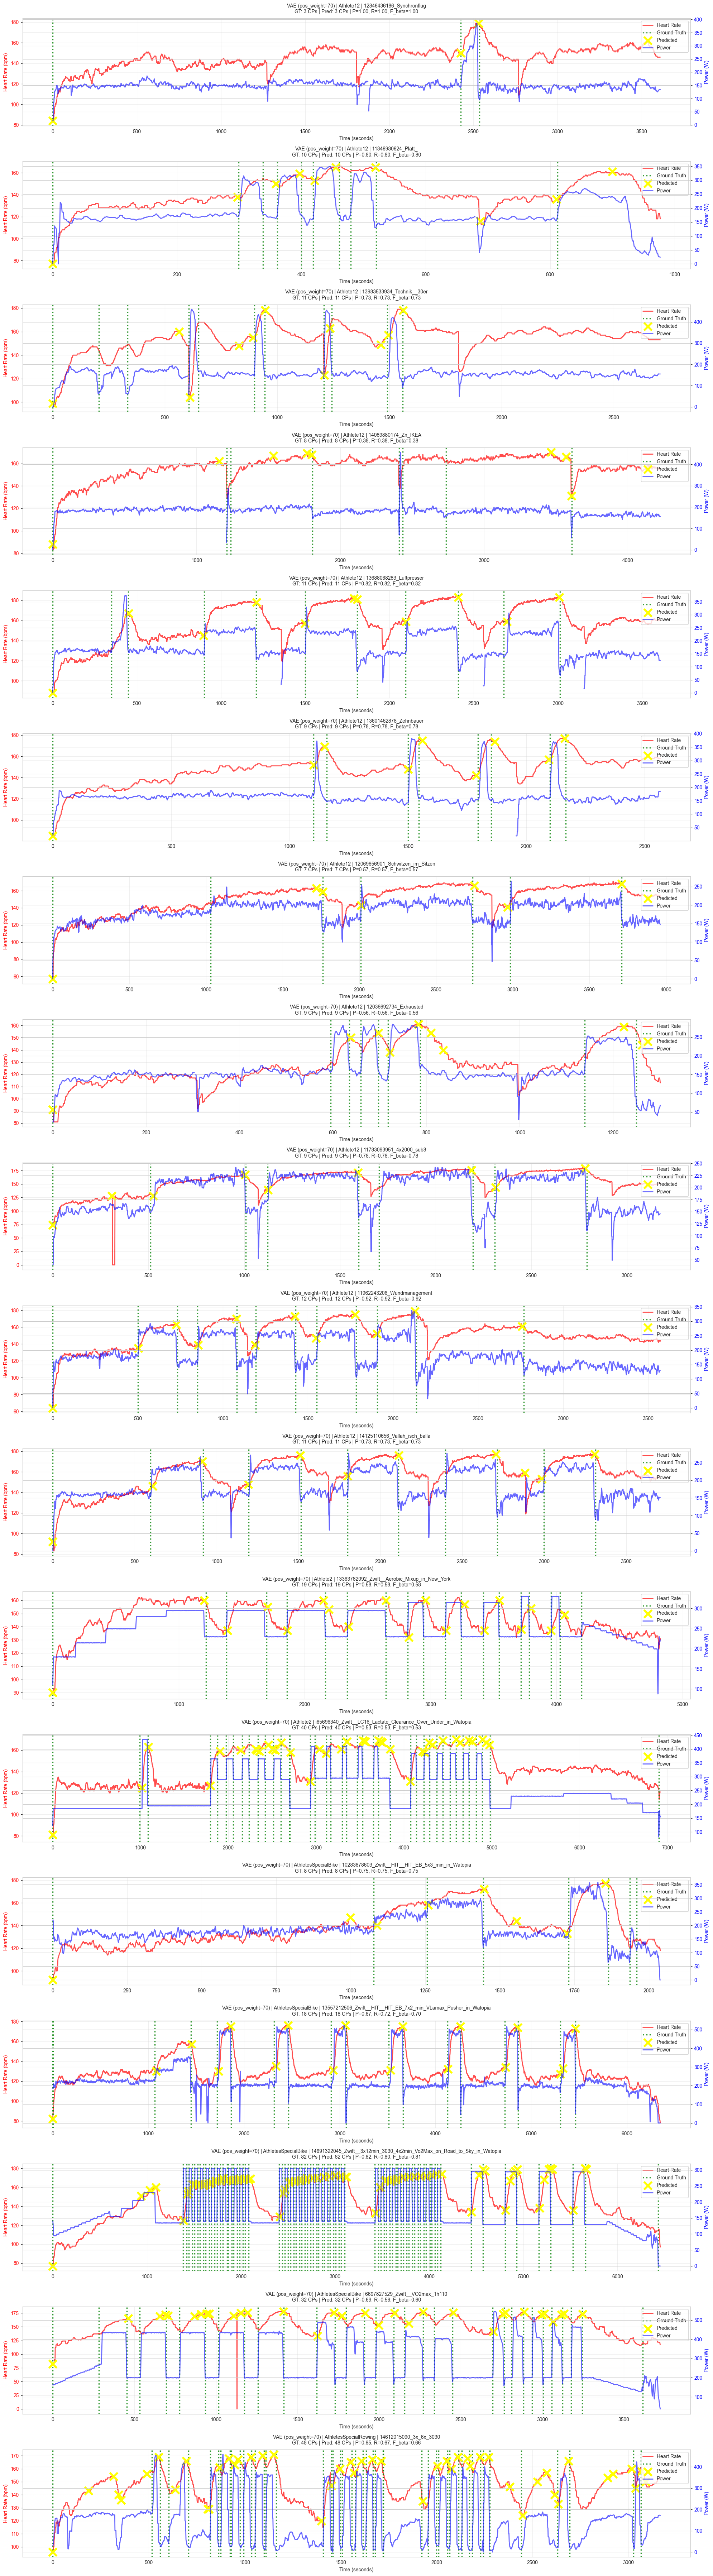

In [16]:
# ============================================================================
# 12. VISUALIZE RESULTS
# ============================================================================

print("\n📊 Plotting VAE predictions...")
plot_test_results(optimized_results, model_name="VAE (pos_weight=70)")